# Seasonal-Naive Baseline (Lag 48)

This notebook generates the seasonal-naive test forecasts required for the F1 degradation curve, for **SA1** and **NSW1** separately. For half-hourly AEMO demand data, 48 intervals equal one day, so the forecast is $\hat{y}_t = y_{t-48}$.

The model is frozen: the lag-48 rule never changes. Actual observations that have already arrived may be used as lagged inputs; this is forecasting, not retraining.

## Key concepts

**Degradation curve (F1)** — A frozen model is trained (or defined) once and never updated, even as new data arrives. "Degradation" is what happens when the real-world process drifts away from what that frozen model assumes, so its forecast error grows over time. The F1 curve is a plot of a rolling error metric against time for each frozen baseline; a rising line means the model is degrading (a sign of concept drift), a flat line means it's still keeping pace. This notebook produces the seasonal-naive line of that curve — later notebooks will overlay the classical and gradient-boosted model lines on the same axis.

**Seasonal-naive & lag** — Seasonal-naive is the simplest possible frozen baseline: it never learns anything and is never retrained. Its forecast at time $t$ is just the observed value one season ago, $\hat{y}_t = y_{t-L}$, where $L$ is the "lag." AEMO demand is recorded every 30 minutes, and one full day = 48 such intervals, so $L=48$ ("lag 48") means the forecast for any half-hour is literally "same time yesterday."

**MAE** — Mean Absolute Error, $\frac{1}{n}\sum_i |y_i - \hat{y}_i|$, measured in MW (same units as demand). It's the average size of the forecast miss — e.g. an MAE of 150 MW means forecasts are typically off by about 150 MW, too high or too low.

**Rolling MAE (7-day)** — Rather than a single MAE number for the whole test period, MAE is recomputed on a sliding 7-day window (336 half-hourly forecasts) ending at every timestamp. This turns one summary statistic into a time series, which is what makes degradation visible: a rising or widening rolling-MAE line means the frozen lag-48 rule is missing by more, more often, as time goes on. A 7-day window is used (rather than 1 day) to smooth out normal weekday/weekend noise while staying short enough to localize *when* things got worse.

In [24]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

from drift_forecasting.config import (
    PROCESSED_DATA_DIR,
    REGIONS,
    ROLLING_WINDOW_DAYS,
    SEASON_LENGTH,
)

## 1. Load the frozen splits for each region

The train / calibration / test split is frozen by `config.SPLIT` and was already applied by [`splits.py`](../../src/drift_forecasting/data/splits.py), which wrote `{REGION}_train.csv`, `{REGION}_calibration.csv`, and `{REGION}_test.csv` to `data/processed/`. This notebook only reads those files, for both regions in `config.REGIONS`.

In [25]:
TIMESTAMP_COLUMN = "SETTLEMENTDATE"
TARGET_COLUMN = "TOTALDEMAND"
SEASONAL_LAG = SEASON_LENGTH  # 48 half-hourly intervals = 1 day
ROLLING_WINDOW = ROLLING_WINDOW_DAYS * SEASON_LENGTH  # 336 half-hourly forecasts


def load_split(region: str, split_name: str) -> pd.DataFrame:
    path = PROCESSED_DATA_DIR / f"{region}_{split_name}.csv"
    df = pd.read_csv(path)
    df[TIMESTAMP_COLUMN] = pd.to_datetime(df[TIMESTAMP_COLUMN])
    return df.sort_values(TIMESTAMP_COLUMN).reset_index(drop=True)


splits = {}

for region in REGIONS:
    splits[region] = {
        "train": load_split(region, "train"),
        "calibration": load_split(region, "calibration"),
        "test": load_split(region, "test"),
    }

    print(f"{region}")
    for split_name, split_df in splits[region].items():
        print(
            f"  {split_name}: {split_df[TIMESTAMP_COLUMN].min()} "
            f"to {split_df[TIMESTAMP_COLUMN].max()} "
            f"({len(split_df):,} rows)"
        )

SA1
  train: 2018-01-01 00:30:00 to 2019-12-31 23:30:00 (35,039 rows)
  calibration: 2020-01-01 00:00:00 to 2020-02-29 23:30:00 (2,880 rows)
  test: 2020-03-01 00:00:00 to 2024-01-01 00:00:00 (67,249 rows)
NSW1
  train: 2018-01-01 00:30:00 to 2019-12-31 23:30:00 (35,039 rows)
  calibration: 2020-01-01 00:00:00 to 2020-02-29 23:30:00 (2,880 rows)
  test: 2020-03-01 00:00:00 to 2024-01-01 00:00:00 (67,249 rows)


## 2. Generate frozen seasonal-naive forecasts

For each region, the splits are concatenated only to obtain observations immediately before the test period (so the first test day can use already-known calibration observations). This does not fit or update a model — the prediction for each timestamp is simply the observed demand 48 rows earlier.

In [26]:
def seasonal_naive_forecast(region_splits: dict[str, pd.DataFrame]) -> pd.DataFrame:
    history = (
        pd.concat(
            [region_splits["train"], region_splits["calibration"], region_splits["test"]],
            ignore_index=True,
        )
        .sort_values(TIMESTAMP_COLUMN)
        .reset_index(drop=True)
    )

    history["PREDICTION"] = history[TARGET_COLUMN].shift(SEASONAL_LAG)

    test_start = region_splits["test"][TIMESTAMP_COLUMN].min()
    test_end = region_splits["test"][TIMESTAMP_COLUMN].max()

    results = history.loc[
        history[TIMESTAMP_COLUMN].between(test_start, test_end),
        [TIMESTAMP_COLUMN, TARGET_COLUMN, "PREDICTION"],
    ].copy()

    missing_predictions = results["PREDICTION"].isna().sum()
    if missing_predictions:
        raise ValueError(f"Test set contains {missing_predictions} missing predictions")

    results["ABSOLUTE_ERROR"] = (results[TARGET_COLUMN] - results["PREDICTION"]).abs()

    results["ROLLING_MAE_7D"] = (
        results["ABSOLUTE_ERROR"]
        .rolling(window=ROLLING_WINDOW, min_periods=ROLLING_WINDOW)
        .mean()
    )

    return results


seasonal_results = {
    region: seasonal_naive_forecast(region_splits)
    for region, region_splits in splits.items()
}

for region, results in seasonal_results.items():
    print(region)
    display(results.head())

SA1


,SETTLEMENTDATE,TOTALDEMAND,PREDICTION,ABSOLUTE_ERROR,ROLLING_MAE_7D
37919,2020-03-01 00:00:00,1377.68,1412.56,34.88,NaN
37920,2020-03-01 00:30:00,1330.34,1365.10,34.76,NaN
37921,2020-03-01 01:00:00,1261.70,1305.29,43.59,NaN
37922,2020-03-01 01:30:00,1182.48,1230.98,48.50,NaN
37923,2020-03-01 02:00:00,1129.30,1193.63,64.33,NaN


NSW1


,SETTLEMENTDATE,TOTALDEMAND,PREDICTION,ABSOLUTE_ERROR,ROLLING_MAE_7D
37919,2020-03-01 00:00:00,7019.06,7146.84,127.78,NaN
37920,2020-03-01 00:30:00,6843.16,6991.19,148.03,NaN
37921,2020-03-01 01:00:00,6674.67,6783.37,108.70,NaN
37922,2020-03-01 01:30:00,6417.07,6503.91,86.84,NaN
37923,2020-03-01 02:00:00,6221.79,6347.40,125.61,NaN


## 3. Inspect the forecasts and errors

In [27]:
for region, results in seasonal_results.items():
    print(f"{region}")
    print(f"  Test forecasts: {len(results):,}")
    print(f"  Overall test MAE: {results['ABSOLUTE_ERROR'].mean():,.2f} MW")
    print(f"  Missing forecasts: {results['PREDICTION'].isna().sum()}")
    print(
        "  Initial rolling-MAE values unavailable by design: "
        f"{results['ROLLING_MAE_7D'].isna().sum()}"
    )

for region, results in seasonal_results.items():
    print(region)
    display(results[[
        TIMESTAMP_COLUMN, TARGET_COLUMN, "PREDICTION",
        "ABSOLUTE_ERROR", "ROLLING_MAE_7D"
    ]].tail())

SA1
  Test forecasts: 67,249
  Overall test MAE: 155.87 MW
  Missing forecasts: 0
  Initial rolling-MAE values unavailable by design: 335
NSW1
  Test forecasts: 67,249
  Overall test MAE: 442.27 MW
  Missing forecasts: 0
  Initial rolling-MAE values unavailable by design: 335
SA1


,SETTLEMENTDATE,TOTALDEMAND,PREDICTION,ABSOLUTE_ERROR,ROLLING_MAE_7D
105163,2023-12-31 22:00:00,1285.116667,1278.400000,6.716667,164.602267
105164,2023-12-31 22:30:00,1278.321667,1256.588333,21.733333,164.506042
105165,2023-12-31 23:00:00,1249.976667,1224.385000,25.591667,164.477302
105166,2023-12-31 23:30:00,1237.001667,1216.035000,20.966667,164.444271
105167,2024-01-01 00:00:00,1306.250000,1293.030000,13.220000,164.363765


NSW1


,SETTLEMENTDATE,TOTALDEMAND,PREDICTION,ABSOLUTE_ERROR,ROLLING_MAE_7D
105163,2023-12-31 22:00:00,6968.330000,7249.076667,280.746667,562.895585
105164,2023-12-31 22:30:00,6857.930000,7083.116667,225.186667,562.545124
105165,2023-12-31 23:00:00,6782.018333,6915.866667,133.848333,561.936989
105166,2023-12-31 23:30:00,6663.935000,6700.796667,36.861667,560.769707
105167,2024-01-01 00:00:00,6633.123333,6610.108333,23.015000,559.527366


## 4. Plot the seasonal-naive F1 line

The final F1 figure must place the classical and gradient-boosted rolling-MAE lines on this same axis, one line per region. Documented events can then be loaded from `events.csv` and annotated consistently.

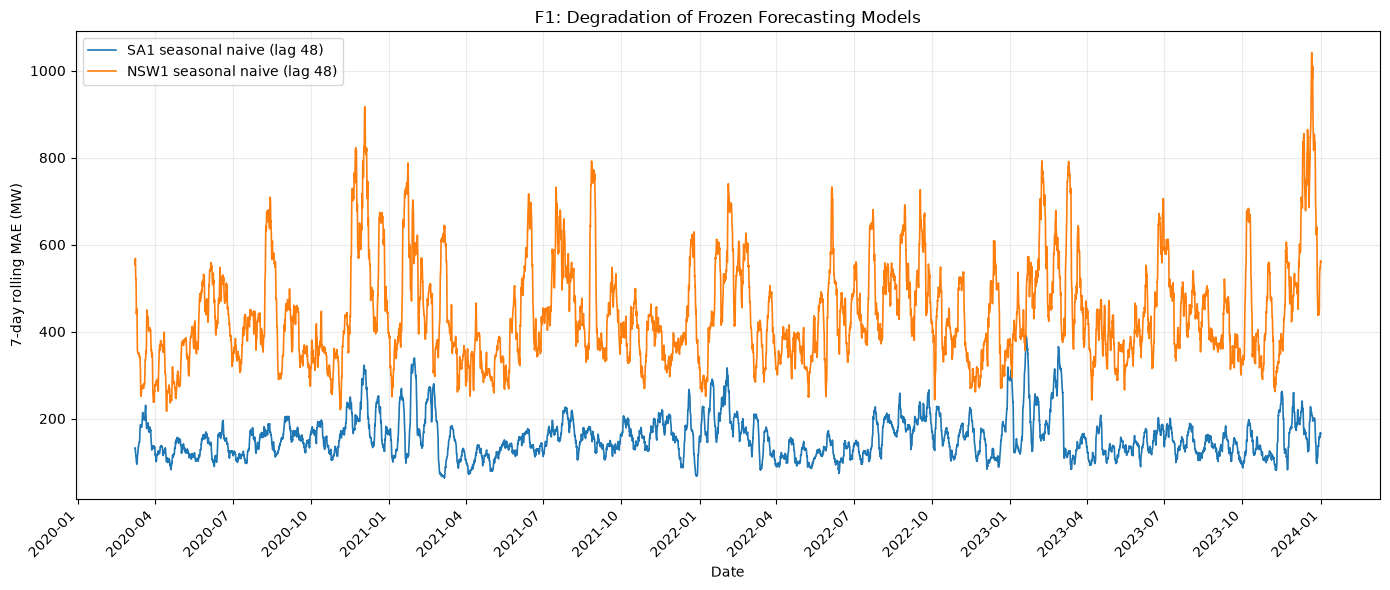

In [28]:
fig, ax = plt.subplots(figsize=(14, 6))

for region, results in seasonal_results.items():
    ax.plot(
        results[TIMESTAMP_COLUMN],
        results["ROLLING_MAE_7D"],
        label=f"{region} seasonal naive (lag 48)",
        linewidth=1.2,
    )

ax.set_title("F1: Degradation of Frozen Forecasting Models")
ax.set_xlabel("Date")
ax.set_ylabel("7-day rolling MAE (MW)")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate(rotation=45)
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

**What the combined plot shows:** error is cyclical rather than a single one-off break — both lines repeatedly rise and fall over the ~4 test years, tracking the Australian seasons: rolling MAE peaks every summer (roughly Nov–Feb) and troughs every autumn (roughly Mar–May). NSW1 sits well above SA1 throughout, consistent with NSW1's much larger absolute demand.

The first clear degradation episode for both regions is **Nov 2020 – Feb 2021**: after a comparatively calm Mar–Oct 2020 (the start of the test period), rolling MAE roughly doubles for NSW1 (peaking near 917 MW on 2020-12) and rises by ~80% for SA1 (peaking near 339 MW in Jan 2021). The same summer pattern then recurs every year, so this is best read as a recurring seasonal effect rather than a permanent regime change — except at the very end of the series (Nov 2023 – Jan 2024), where the degradation is both the largest on record and does not fully subside before the test data run out; see the per-region plots below for details.

### 4a. Per-region rolling-MAE plots

SA1 and NSW1 sit on very different demand scales, so the combined plot above compresses SA1's degradation pattern. One figure per region, each on its own y-axis, makes each region's pattern easier to read.

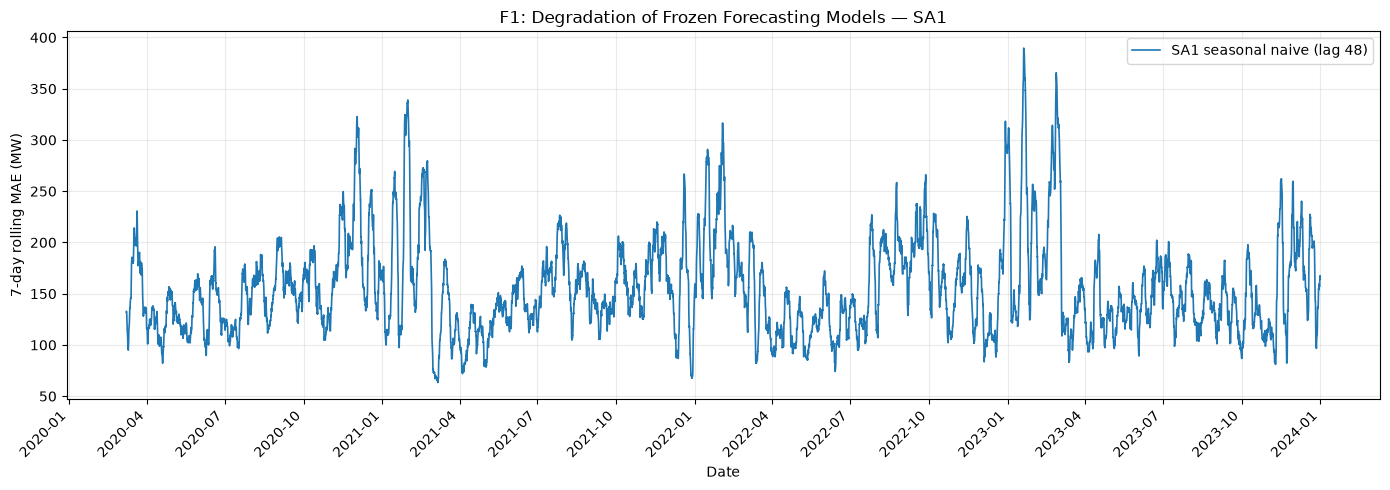

In [29]:
def plot_region(region: str, results: pd.DataFrame, color: str) -> None:
    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(
        results[TIMESTAMP_COLUMN],
        results["ROLLING_MAE_7D"],
        label=f"{region} seasonal naive (lag 48)",
        linewidth=1.2,
        color=color,
    )

    ax.set_title(f"F1: Degradation of Frozen Forecasting Models — {region}")
    ax.set_xlabel("Date")
    ax.set_ylabel("7-day rolling MAE (MW)")
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    fig.autofmt_xdate(rotation=45)
    ax.grid(alpha=0.25)
    ax.legend()

    fig.tight_layout()
    plt.show()


plot_region("SA1", seasonal_results["SA1"], color="tab:blue")

**SA1:** Mar–Oct 2020 is the calmest stretch of the whole series, averaging ~120–160 MW rolling MAE. Degradation first becomes visible in **Nov 2020 – Feb 2021**, where the monthly-average rolling MAE rises to ~190–205 MW (max 339 MW in Jan 2021) — roughly 30–70% above the initial baseline. This summer-degradation pattern then repeats every year (evident as the recurring peaks each Nov–Feb), with the single worst episode occurring in **Jan–Feb 2023**, where rolling MAE reaches its dataset maximum of 389.7 MW on 2023-01-19. Winters (roughly Apr–Jun) consistently pull error back down to the ~110–150 MW range, so SA1's degradation looks seasonal and recurring rather than a one-time permanent shift.

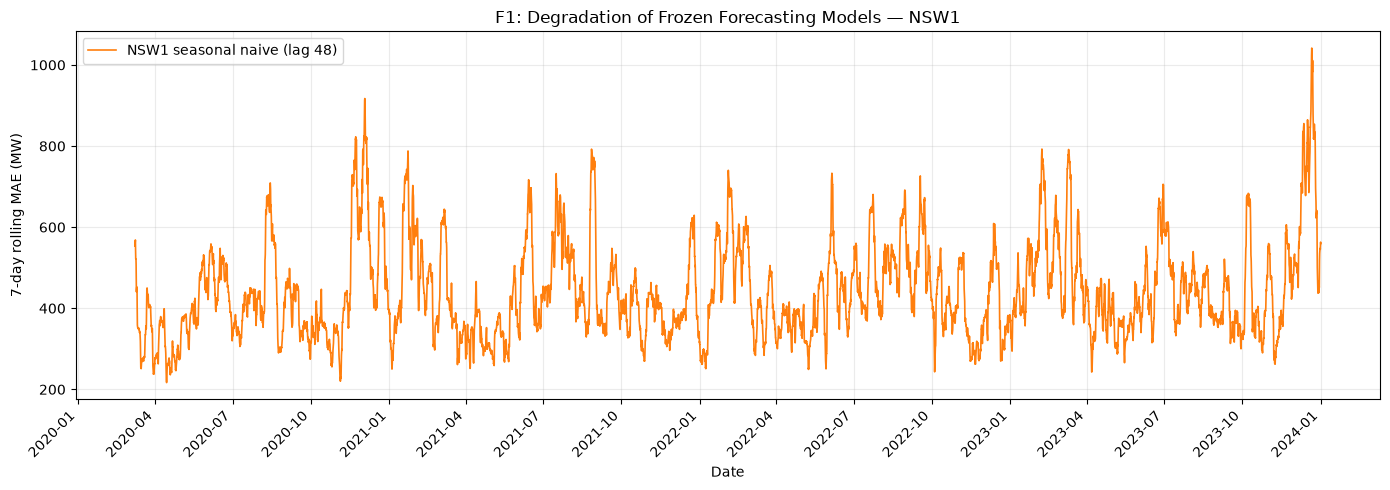

In [30]:
plot_region("NSW1", seasonal_results["NSW1"], color="tab:orange")

**NSW1:** the baseline level is noisier than SA1's and less confined to summer — winter months (e.g. Jun–Aug 2021 and Jun–Sep 2022) also sit at 470–530 MW, comparable to summer levels, so NSW1's frozen forecast is less cleanly seasonal than SA1's. The first clear degradation episode is still **Nov–Dec 2020**, where rolling MAE jumps from a ~300–470 MW baseline to a monthly average of 515–576 MW (max 917 MW on 2020-12). The standout feature of this plot is the **final two months of the series (Dec 2023 – Jan 2024)**: rolling MAE climbs to its dataset maximum of 1,041.6 MW on 2023-12-21 — noticeably higher than any earlier summer peak — and is still elevated (monthly average 559.5 MW) when the test data end on 2024-01-01, i.e. this episode had not recovered before the series stops, unlike every earlier summer spike.

**Suggested caption:** Seven-day rolling mean absolute error (336 half-hourly forecasts) of the frozen baseline models over the test stream, for SA1 and NSW1. The seasonal-naive baseline predicts each value using observed demand 48 intervals earlier. Documented events provide contextual reference points and are not treated as ground-truth changepoints.